<a href="https://colab.research.google.com/github/andrebenga/Senai-Programacao-em-IA-Generativa/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 05 - Projeto Prático (Colab)
## Projeto Real: "Previsão de Churn (Cancelamento) com MLP e Keras"

## Objetivo: Construir uma Rede Neural (MLP) para prever se um cliente
## de telecomunicações irá cancelar o serviço (Churn), baseado em
## seus dados de contrato, uso e pagamento.

In [2]:
# ----------------------------------------------------
# Bloco 1: Importações e Setup (Corrigido para Visuais)
# ----------------------------------------------------
print("--- Bloco 1: Importando Bibliotecas ---")
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt # Para gráficos
import seaborn as sns           # Para a Matriz de Confusão

# LACUNA 1: Importe as camadas (layers) e modelos (models) do Keras
from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# (Pronto) Importar as métricas que precisamos
from sklearn.metrics import confusion_matrix, classification_report

print("Bibliotecas carregadas!")

--- Bloco 1: Importando Bibliotecas ---
Bibliotecas carregadas!


In [3]:
# ----------------------------------------------------
# Bloco 2: Carga e Exploração dos Dados
# ----------------------------------------------------
print("\n--- Bloco 2: Carregando os Dados (Telco Churn) ---")
# (Pronto) Vamos baixar o dataset de um link estável
!wget -q "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# (Pronto) Carregar no Pandas
data = pd.read_csv('Telco-Customer-Churn.csv')

print("Dados carregados. 5 primeiras linhas:")
display(data.head())

# (Pronto) Ver informações das colunas
print("\nInformações das Colunas (Tipos de Dados):")
data.info()


--- Bloco 2: Carregando os Dados (Telco Churn) ---
Dados carregados. 5 primeiras linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informações das Colunas (Tipos de Dados):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16 

In [4]:
# ----------------------------------------------------
# Bloco 3: Pré-Processamento (A "Engenharia" Real - VERSÃO CORRIGIDA)
# ----------------------------------------------------
print("\n--- Bloco 3: Pré-Processamento dos Dados ---")

# LACUNA 2: Converta a coluna 'Churn'
# Dica: Se o valor (x) for 'Yes', retorne 1, senão (else) retorne 0
data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# (Pronto) TotalCharges é lido como 'object' (texto). Precisamos converter.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# (Pronto) Separar as features (X) do target (y)
X = data.drop(['customerID', 'Churn'], axis=1)
y = data['Churn'] # 'y' agora é 0 ou 1 (numérico)

# (Pronto) Identificar quais colunas são numéricas e quais são texto
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
target = 'Churn'
categorical_features = [col for col in X.columns if col not in numeric_features and not target]

# (Pronto) Criar o "pipeline" de transformação para dados numéricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche 'NaN'
    ('scaler', StandardScaler())                   # Coloca na mesma escala
])

# (Pronto) Criar o "pipeline" para dados categóricos
# Adicionamos sparse_output=False para que a saída seja um array denso.
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


# (Pronto) O 'ColumnTransformer' aplica a transformação certa na coluna certa
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# (Pronto) Aplicar o pré-processamento
X_processed = preprocessor.fit_transform(X)

# --- CORREÇÃO DA CAUSA DO ERRO ---
# LACUNA 3: Separe os dados PROCESSADOS (X_processed) em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.5, random_state=42)

# (Pronto) Forçamos os tipos de dados para float32, que o Keras/JAX espera.
X_train = np.asarray(X_train).astype('float32')
X_test = np.asarray(X_test).astype('float32')
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

print(f"\nDados processados e prontos!")
print(f"Shape (formato) do X_train: {X_train.shape}")
print(f"Tipo de dado do X_train: {X_train.dtype}") # (Deve ser float32)
print(f"Tipo de dado do y_train: {y_train.dtype}") # (Deve ser float32)


--- Bloco 3: Pré-Processamento dos Dados ---

Dados processados e prontos!
Shape (formato) do X_train: (3521, 3)
Tipo de dado do X_train: float32
Tipo de dado do y_train: float32


In [10]:
# ----------------------------------------------------
# Bloco 4: Construindo o Modelo MLP (Keras)
# ----------------------------------------------------
print("\n--- Bloco 4: Construindo o Modelo MLP (Deep Learning) ---")

# LACUNA 4: Inicie um modelo 'Sequential' (o "container")
model = models.Sequential()

# (Pronto) Definimos a camada de entrada (Input)
# O shape de entrada (input_shape) DEVE ser igual ao número de colunas do X_train
input_shape = [X_train.shape[1]]

# LACUNA 5: Adicione a 1ª Camada Oculta 'Dense'
# (Vamos usar 32 neurônios e ativação 'relu')
model.add(layers.Dense(units=32, activation='relu'))

# (Pronto) Adicionamos uma segunda camada oculta para tornar a rede "Deep"
model.add(layers.Dense(units=16, activation='relu'))

# (Pronto) Vamos adicionar 'Dropout' (uma técnica para evitar Overfitting)
# Ela "desliga" aleatoriamente 20% dos neurônios durante o treino
model.add(layers.Dropout(0.2))

# LACUNA 6: Adicione a Camada de Saída 'Dense'
# Dica: É um problema binário (Churn/Não Churn)
model.add(layers.Dense(units=1, activation='sigmoid'))

print("Arquitetura do Modelo:")
model.summary() # Imprime a arquitetura


--- Bloco 4: Construindo o Modelo MLP (Deep Learning) ---
Arquitetura do Modelo:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ----------------------------------------------------
# Bloco 5: Compilar e Treinar
# ----------------------------------------------------
print("\n--- Bloco 5: Compilando e Treinando ---")

# LACUNA 7: Compile o modelo
# Dica: 'optimizer' (como o modelo aprende) = 'adam'
# Dica: 'loss' (como medimos o erro binário) = 'binary_crossentropy'
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# LACUNA 8: Treine o modelo usando '.fit()'
# Dica: Treine por 20 aula
# Dica 2: Use os dados de validação (X_test, y_test) para ver o progresso
print("\n--- INICIANDO TREINAMENTO ---")
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1 # (Mostra o progresso)
)
print("--- TREINAMENTO CONCLUÍDO ---")


--- Bloco 5: Compilando e Treinando ---

--- INICIANDO TREINAMENTO ---
Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7120 - loss: 0.5763 - val_accuracy: 0.7842 - val_loss: 0.4850
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7668 - loss: 0.4880 - val_accuracy: 0.7905 - val_loss: 0.4632
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7722 - loss: 0.4739 - val_accuracy: 0.7913 - val_loss: 0.4550
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7722 - loss: 0.4699 - val_accuracy: 0.7907 - val_loss: 0.4509
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7728 - loss: 0.4691 - val_accuracy: 0.7871 - val_loss: 0.4509
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7739 - loss: 0.4656 - val_accuracy: 0.7922 - val_loss: 0.4468
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7842 - loss: 0.4649 - val_accuracy: 0.7933 - val_loss: 0.4464
Epoch 8/20
111/111 ━━━━━━━━━━━━━


--- Bloco 6: Avaliando o resultado ---
Visualizando o Histórico de Treinamento (Acurácia e Erro)...


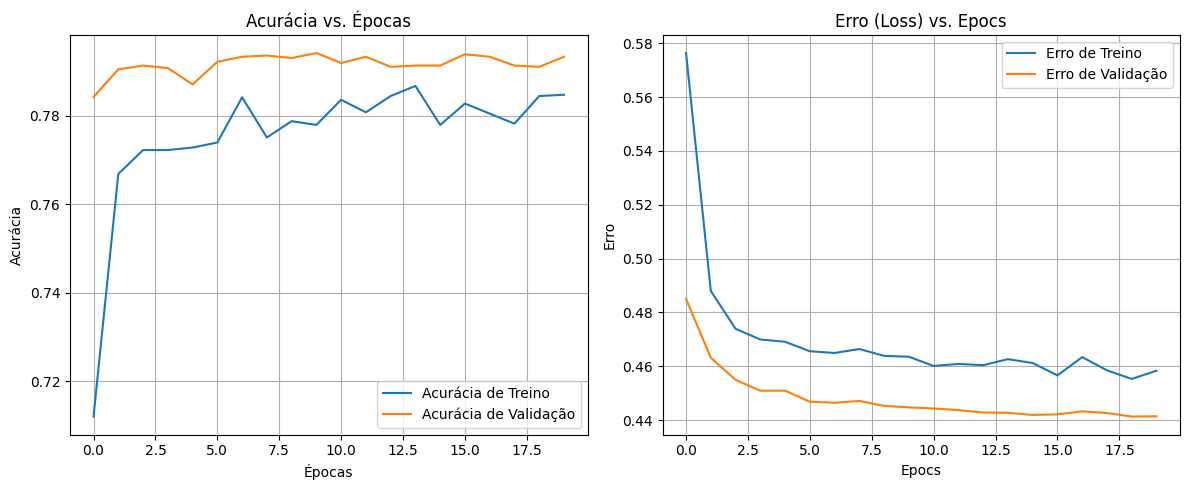


--- Avaliando o Modelo no Set de Teste ---
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7933 - loss: 0.4414

Acurácia Final no Teste: 79.33%
Erro (Loss) Final no Teste: 0.4414

--- Matriz de Confusão (Impacto no Negócio) ---
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


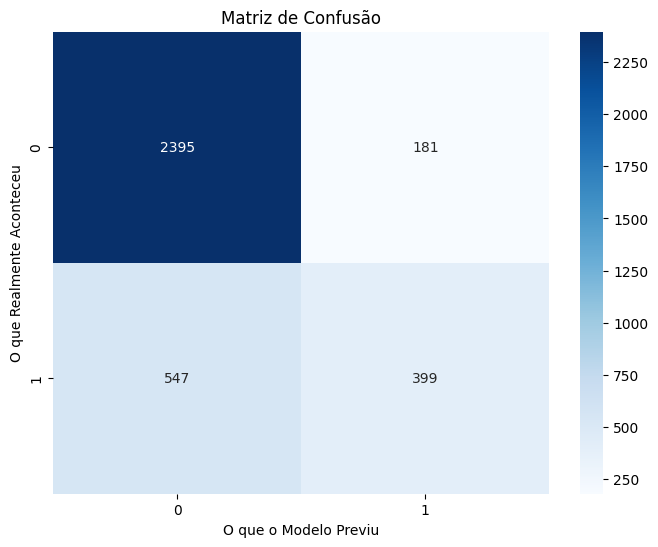


--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

   Não Churn       0.81      0.93      0.87      2576
       Churn       0.69      0.42      0.52       946

    accuracy                           0.79      3522
   macro avg       0.75      0.68      0.70      3522
weighted avg       0.78      0.79      0.78      3522



In [14]:
# ----------------------------------------------------
# Bloco 6: Avaliar o Modelo (VERSÃO VISUAL)
# ----------------------------------------------------
print("\n--- Bloco 6: Avaliando o resultado ---")

# (Pronto) Vamos primeiro plotar o histórico de treino
print("Visualizando o Histórico de Treinamento (Acurácia e Erro)...")

# Criar um DataFrame com o histórico
history_df = pd.DataFrame(history.history)

# Plotar Acurácia (Treino vs Validação)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Acurácia de Treino')
plt.plot(history_df['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia vs. Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

# Plotar Erro (Loss) (Treino vs Validação)
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Erro de Treino')
plt.plot(history_df['val_loss'], label='Erro de Validação')
plt.title('Erro (Loss) vs. Epocs')
plt.xlabel('Epocs')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.tight_layout() # Ajusta o layout
plt.show()


print("\n--- Avaliando o Modelo no Set de Teste ---")

# LACUNA 9: Avalie o modelo nos dados de teste
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nAcurácia Final no Teste: {accuracy*100:.2f}%")
print(f"Erro (Loss) Final no Teste: {loss:.4f}")

# --- A PARTE MAIS IMPORTANTE: O IMPACTO NO NEGÓCIO ---
print("\n--- Matriz de Confusão (Impacto no Negócio) ---")

# (Pronto) Para gerar a matriz, precisamos das previsões do modelo
# O modelo 'sigmoid' retorna probabilidades (ex: 0.8, 0.1, 0.3)
y_pred_prob = model.predict(X_test)

# (Pronto) Convertemos probabilidades em classes (0 ou 1)
# Se a probabilidade for > 0.5, é 1 (Churn), senão 0 (Não Churn)
y_pred = (y_pred_prob > 0.5).astype("int32")

# (Pronto) Gerar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# (Pronto) Plotar a Matriz com Seaborn (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Aconteceu')
plt.show()

print("\n--- Relatório de Classificação Detalhado ---")
# (Pronto) Isso mostra a Precisão (Precision) e Revocação (Recall)
print(classification_report(y_test, y_pred, target_names=['Não Churn', 'Churn']))